# 06. 多域覆盖 & 用户画像分层

> 对应 `analysis_plan.md` §2.6。**依赖 §2.5 的 `_cache.pkl`**（如果没跑请先跑 `05_user_seq_stats.ipynb`）。

## 目的

1. **domain 组合矩阵**：50 万用户在 4 个域上的「有/无历史」二值矩阵 → 15 种非空组合（$2^4-1$）各自的用户数与占比。
2. **单域 vs 多域用户比例**：跨域推荐样本占比够不够？（如果单域用户 >80% 说明训练时多数样本是「输入只有一个域的历史」）。
3. **活跃度分层**：按用户总交互数（4 个域 primary 长度之和）分成 low / mid / high 三层，各层用户数、平均交互数。
4. **domain × 活跃度交叉**：不同活跃度用户的 domain 组合分布，用于 SFT 分层采样。

## 输入 / 输出

**输入**：`analysis/outputs/user_seq/_cache.pkl`（§2.5 已产出，含所有 primary 序列每用户的长度）

**输出**（`analysis/outputs/domain_coverage/`）：
- `combo_stats.csv` —— 15 种 domain 组合的用户数与占比
- `single_vs_multi.csv` —— 单/多域用户数汇总
- `stratum.csv` —— 活跃度分层统计
- `stratum_x_domain.csv` —— 活跃度 × domain 组合交叉表（用于分层采样权重）
- `venn.png` —— 4 域集合韦恩图
- `combo_bars.png`, `stratum_bars.png`
- `_cache.pkl` —— 供后续 notebook 复用

## 关键设计

**用户在 domain d 有历史** ≜ 该 domain 下**任一** primary 序列长度 > 0。这样定义比"某个特定字段非空"更宽松，也更贴近真实情况（一个用户可能只买过东西没点过 goods 展示）。

In [1]:
# ============ 配置 & imports ============
import pickle, itertools
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- macOS 中文字体 ----
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Songti SC', 'STHeiti', 'Hiragino Sans GB', 'PingFang SC', 'Heiti SC', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT   = Path('/Users/cjs/Desktop/MY/explore_llm_rec')
SEQ_CACHE_PATH = PROJECT_ROOT / 'analysis' / 'outputs' / 'user_seq' / '_cache.pkl'
OUT_DIR        = PROJECT_ROOT / 'analysis' / 'outputs' / 'domain_coverage'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH     = OUT_DIR / '_cache.pkl'

# domain -> primary fields（同 §2.5 的定义）
PRIMARY = {
    'video/video': [
        'video_sampled_pid_list',
        'video_history_sampled_pid_list',
    ],
    'goods': [
        'ec_item_id_list',
        'ec_good_click_item_id_list_extend',
        'ec_good_order_item_id_list_extend',
        'ec_colossus_rs_item_id_list',
    ],
    'live': ['live_hist_author_id_list'],
    'video/ad': [
        'outer_loop_history_action_pid_list_pos',
        'outer_loop_history_action_pid_list_click',
        'outer_loop_deep_target_pid',
    ],
}

print(f'Seq cache: {SEQ_CACHE_PATH}')
print(f'Output   : {OUT_DIR}')
assert SEQ_CACHE_PATH.exists(), 'Please run 05_user_seq_stats.ipynb first!'

with open(SEQ_CACHE_PATH, 'rb') as f:
    seq_stats = pickle.load(f)
print(f'total_rows: {seq_stats["total_rows"]:,}')

Seq cache: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/user_seq/_cache.pkl
Output   : /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/domain_coverage
total_rows: 500,000


## 步骤 1：构建用户 × domain 布尔矩阵 + 每用户交互总数

对每个 primary 字段的长度数组做 element-wise OR，得到"该 domain 的每个用户是否有任一 primary 序列非空"。

同时对每 domain 累加 `sum of primary lens` 作为该 domain 的交互次数（含重复）。用户总交互数 = 四域交互数之和。

In [2]:
domains = list(PRIMARY.keys())
n_users = seq_stats['total_rows']

# per-user boolean per domain (True = 该域有历史)
has_domain = {}
domain_events = {}   # per-user 交互次数（该域 primary 长度之和）

for d, fields in PRIMARY.items():
    m = np.zeros(n_users, dtype=bool)
    total = np.zeros(n_users, dtype=np.int64)
    for f in fields:
        arr = seq_stats['lens'].get(f)
        if arr is None:
            continue
        # 有可能不同 field 长度不齐（不该发生，但为鲁棒性做检查）
        if arr.shape[0] != n_users:
            print(f'  ⚠ {f} length {arr.shape[0]} != n_users {n_users}, skip')
            continue
        m |= (arr > 0)
        total += arr.astype(np.int64)
    has_domain[d] = m
    domain_events[d] = total
    print(f'  {d:<12s}  active_users={int(m.sum()):>7,}  ({m.sum()/n_users*100:.1f}%)  '
          f'total_events={int(total.sum()):,}')

user_total_events = sum(domain_events.values())
print(f'\nglobal total events: {user_total_events.sum():,}')

  video/video   active_users=500,000  (100.0%)  total_events=411,072,859
  goods         active_users=351,337  (70.3%)  total_events=258,270,445
  live          active_users=359,669  (71.9%)  total_events=35,580,635
  video/ad      active_users=355,463  (71.1%)  total_events=29,693,374

global total events: 734,617,313


## §2.6.1 15 种 domain 组合分布

对每个用户构造 4-bit 编码 (video, goods, live, ad) → 分类。0000 是完全空用户（预期为 0）。

In [3]:
code = np.zeros(n_users, dtype=np.int8)
for i, d in enumerate(domains):
    code += (has_domain[d].astype(np.int8) << i)   # bit i = domain i

combo_rows = []
for c in range(16):
    n = int((code == c).sum())
    if n == 0 and c != 0:
        continue
    active = [domains[i] for i in range(4) if (c >> i) & 1]
    combo_rows.append({
        'code_bits':    format(c, '04b'),
        'active_domains': ' + '.join(active) if active else '(none)',
        'n_users':      n,
        'user_%':       round(n / n_users * 100, 3),
        'n_active_domains': len(active),
    })

combo_df = pd.DataFrame(combo_rows).sort_values('n_users', ascending=False).reset_index(drop=True)
combo_df.to_csv(OUT_DIR / 'combo_stats.csv', index=False)
print('saved:', OUT_DIR / 'combo_stats.csv')
combo_df

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/domain_coverage/combo_stats.csv


,code_bits,active_domains,n_users,user_%,n_active_domains
0,1111,video/video + goods + live + video/ad,207525,41.505,4
1,1101,video/video + live + video/ad,65241,13.048,3
2,0111,video/video + goods + live,58099,11.620,3
3,1011,video/video + goods + video/ad,55005,11.001,3
4,0011,video/video + goods,30708,6.142,2
5,0101,video/video + live,28804,5.761,2
6,1001,video/video + video/ad,27692,5.538,2
7,0001,video/video,26926,5.385,1
8,0000,(none),0,0.000,0


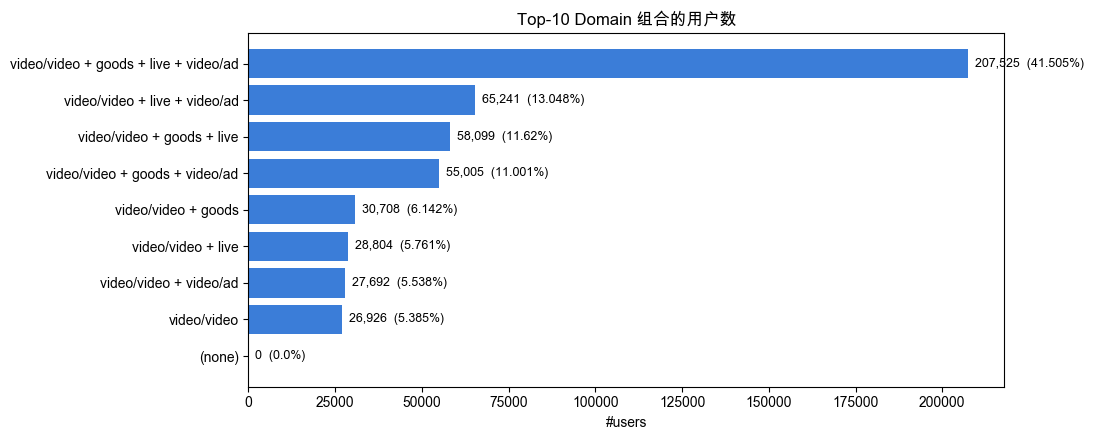

In [4]:
# 前 10 组合的柱状图
top = combo_df.head(10)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.barh(top['active_domains'][::-1], top['n_users'][::-1], color='#3b7dd8')
for i, (v, p) in enumerate(zip(top['n_users'][::-1], top['user_%'][::-1])):
    ax.text(v, i, f'  {v:,}  ({p}%)', va='center', fontsize=9)
ax.set_title('Top-10 Domain 组合的用户数')
ax.set_xlabel('#users')
plt.tight_layout()
plt.savefig(OUT_DIR / 'combo_bars.png', dpi=110)
plt.show()

## §2.6.2 单域 vs 多域用户

In [5]:
n_active = np.zeros(n_users, dtype=np.int8)
for d in domains:
    n_active += has_domain[d].astype(np.int8)

sm_rows = []
for k in range(5):  # 0~4 domains
    n = int((n_active == k).sum())
    sm_rows.append({
        'n_active_domains': k,
        'n_users':          n,
        'user_%':           round(n / n_users * 100, 3),
    })
sm_df = pd.DataFrame(sm_rows)
sm_df.to_csv(OUT_DIR / 'single_vs_multi.csv', index=False)
print('saved:', OUT_DIR / 'single_vs_multi.csv')
print(sm_df)
print(f'\n单域用户占比:      {(n_active == 1).mean() * 100:.2f}%')
print(f'多域(2+)用户占比:  {(n_active >= 2).mean() * 100:.2f}%')
print(f'全 4 域活跃用户:   {(n_active == 4).mean() * 100:.2f}%')

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/domain_coverage/single_vs_multi.csv
   n_active_domains  n_users  user_%
0                 0        0   0.000
1                 1    26926   5.385
2                 2    87204  17.441
3                 3   178345  35.669
4                 4   207525  41.505

单域用户占比:      5.39%
多域(2+)用户占比:  94.61%
全 4 域活跃用户:   41.50%


## §2.6.3 4 域韦恩图（可选：如果 matplotlib_venn 有 venn4 支持则用；没有降级为 upset-like 表）

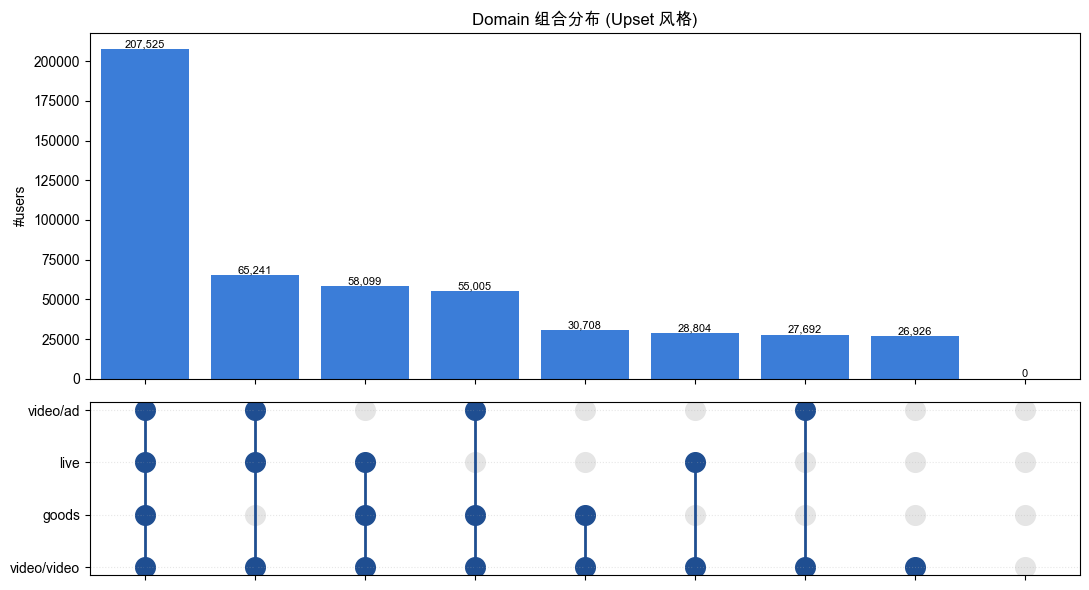

In [6]:
# matplotlib_venn 只有 venn2/venn3；venn4 需要 upsetplot 或手绘
# 这里画一张 UpSet 风格的表：每种组合的用户数（已在 combo_stats.csv 里）
import matplotlib.patches as patches

top_combos = combo_df.head(15)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), gridspec_kw={'height_ratios': [3, 1.5]}, sharex=True)

# top: bar
ax1.bar(range(len(top_combos)), top_combos['n_users'], color='#3b7dd8')
for i, v in enumerate(top_combos['n_users']):
    ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
ax1.set_ylabel('#users')
ax1.set_title('Domain 组合分布 (Upset 风格)')

# bottom: which domains active (grid)
for i, code_bits in enumerate(top_combos['code_bits']):
    for j, d in enumerate(domains):
        active = int(code_bits[3 - j])   # bit j
        color = '#1f4e91' if active else '#e5e5e5'
        ax2.scatter(i, j, s=200, c=color)
    active_idx = [j for j, d in enumerate(domains) if int(code_bits[3 - j])]
    if len(active_idx) >= 2:
        ax2.plot([i]*len(active_idx), active_idx, color='#1f4e91', lw=2)

ax2.set_yticks(range(len(domains)))
ax2.set_yticklabels(domains)
ax2.set_xticks(range(len(top_combos)))
ax2.set_xticklabels([]) 
ax2.grid(axis='y', ls=':', alpha=0.3)
ax2.set_xlim(-0.5, len(top_combos) - 0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'venn.png', dpi=110)
plt.show()

## §2.6.4 活跃度分层（low / mid / high）

按用户总交互数（4 域 primary 长度之和）三分位分层：
- **low**：0~P33
- **mid**：P33~P67
- **high**：P67~max

统计每层的用户数、平均交互数、平均活跃 domain 数。

In [7]:
total_ev = user_total_events
p33 = np.percentile(total_ev, 33.33)
p67 = np.percentile(total_ev, 66.67)

layer = np.full(n_users, 'mid', dtype=object)
layer[total_ev <= p33] = 'low'
layer[total_ev > p67]  = 'high'

# 活跃度分层统计
st_rows = []
for lv in ['low', 'mid', 'high']:
    mask = layer == lv
    st_rows.append({
        'layer':                 lv,
        'n_users':               int(mask.sum()),
        'user_%':                round(mask.mean() * 100, 2),
        'mean_events_per_user':  round(float(total_ev[mask].mean()), 1) if mask.sum() else 0,
        'p50_events':            int(np.percentile(total_ev[mask], 50)) if mask.sum() else 0,
        'p90_events':            int(np.percentile(total_ev[mask], 90)) if mask.sum() else 0,
        'mean_active_domains':   round(float(n_active[mask].mean()), 2) if mask.sum() else 0,
    })
st_df = pd.DataFrame(st_rows)
st_df.to_csv(OUT_DIR / 'stratum.csv', index=False)
print('cutoffs:  P33=%.1f  P67=%.1f' % (p33, p67))
print('saved:', OUT_DIR / 'stratum.csv')
st_df

cutoffs:  P33=1029.0  P67=1670.0
saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/domain_coverage/stratum.csv


,layer,n_users,user_%,mean_events_per_user,p50_events,p90_events,mean_active_domains
0,low,166662,33.33,616.6,605,948,2.53
1,mid,166794,33.36,1361.8,1368,1604,3.32
2,high,166544,33.31,2430.0,2140,3320,3.55


## §2.6.5 活跃度 × domain 组合交叉表

每种 domain 组合下，low/mid/high 各占多少 —— **决定分层采样权重**。

In [8]:
# code 已是 4-bit 编码；layer 是 low/mid/high
cross = pd.crosstab(pd.Series([format(c, '04b') for c in code], name='combo_bits'),
                    pd.Series(layer, name='layer'))
cross['total'] = cross.sum(axis=1)
cross = cross.sort_values('total', ascending=False)

# 加上 human-readable 组合名字
def _bits_to_name(b):
    active = [domains[i] for i in range(4) if int(b[3 - i])]
    return ' + '.join(active) if active else '(none)'
cross.insert(0, 'active_domains', [_bits_to_name(b) for b in cross.index])

cross.to_csv(OUT_DIR / 'stratum_x_domain.csv')
print('saved:', OUT_DIR / 'stratum_x_domain.csv')
cross.head(20)

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/domain_coverage/stratum_x_domain.csv


layer,active_domains,high,low,mid,total
combo_bits,,,,,
1111,video/video + goods + live + video/ad,105368,21680,80477,207525
1101,video/video + live + video/ad,5453,47013,12775,65241
0111,video/video + goods + live,23570,9357,25172,58099
1011,video/video + goods + video/ad,19340,11395,24270,55005
0011,video/video + goods,8139,9448,13121,30708
0101,video/video + live,1876,22649,4279,28804
1001,video/video + video/ad,1569,22311,3812,27692
0001,video/video,1229,22809,2888,26926


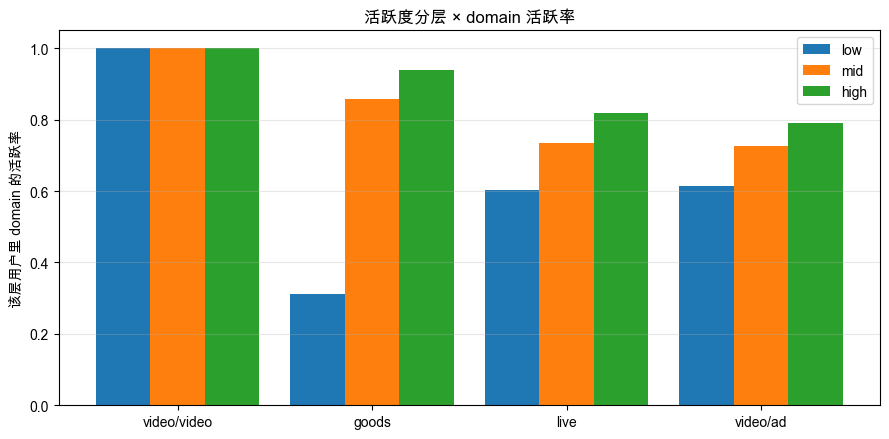

In [9]:
# 每层各 domain 的活跃占比
fig, ax = plt.subplots(figsize=(9, 4.5))
layers = ['low', 'mid', 'high']
x = np.arange(len(domains))
w = 0.28
for i, lv in enumerate(layers):
    mask = layer == lv
    rates = [has_domain[d][mask].mean() for d in domains]
    ax.bar(x + (i - 1) * w, rates, w, label=lv)
ax.set_xticks(x); ax.set_xticklabels(domains)
ax.set_ylabel('该层用户里 domain 的活跃率')
ax.set_title('活跃度分层 × domain 活跃率')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'stratum_bars.png', dpi=110)
plt.show()

In [10]:
# 供后续 notebook 复用
with open(CACHE_PATH, 'wb') as f:
    pickle.dump({
        'has_domain':    has_domain,
        'domain_events': domain_events,
        'code':          code,
        'n_active':      n_active,
        'layer':         layer,
        'domains':       domains,
    }, f)
print(f'[cache] saved to {CACHE_PATH}')

[cache] saved to /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/domain_coverage/_cache.pkl


## §2.6.6 结论 & 对 SFT 的直接指导

抄进 `analysis/report.md`：

1. **单域用户主导 vs 多域用户主导**：如果单域用户 >70%，说明 SFT 里大多数样本是「输入侧只有一个域的历史」→ 需要设计 prompt 模板兼容「有些域为空」的情况（例如占位符 `<|no_history_domain|>`）。
2. **domain 组合的头部效应**：`combo_stats.csv` 前 3 组合覆盖多少用户？如果前 3 覆盖 >80%，其他 12 种组合可考虑合并或降采样，避免长尾组合污染训练。
3. **分层采样权重**：`stratum.csv` 里高活跃层用户交互次数是低活跃层的几倍？如果差距 >100x，需要对高活跃用户做**长度截断+子序列采样**（每个用户产生多个训练样本），对低活跃用户**上采样**（避免高活跃用户主导）。
4. **评估分层报告**：Pass@64 报告不能只看总体，还应按活跃度分层报告 —— low 用户可能 pass rate 极低（历史稀疏无法预测），high 用户容易高（信息量足）。
5. **跨域推荐的天然样本**：多域用户即天然的「跨域推荐样本源」，可以从 `stratum_x_domain.csv` 挑「video + goods 双活跃」的用户构造「video 历史 → goods next」的评测样本。

### 产出物清单（`analysis/outputs/domain_coverage/`）
- `combo_stats.csv` —— 15 种 domain 组合分布
- `single_vs_multi.csv` —— 单/多域用户数
- `stratum.csv` —— 活跃度分层
- `stratum_x_domain.csv` —— 活跃度 × domain 组合交叉
- `combo_bars.png`, `venn.png`, `stratum_bars.png`
- `_cache.pkl` —— 供后续 notebook 复用（含 has_domain / layer / n_active）